In [24]:
import time
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [25]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

In [26]:
df = pd.read_csv("../data/KDDTrain+.txt", names=columns, sep="\t")


print(df.shape)
df.head()

(125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [27]:
y = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Drop label + difficulty
X = df.drop(['label', 'difficulty'], axis=1)

# One-hot encode categorical features
X = pd.get_dummies(X)

print("Features after encoding:", X.shape)

Features after encoding: (125973, 122)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [30]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

In [31]:
print("Original number of features :", X_train.shape[1])
print("Features after PCA          :", X_train_pca.shape[1])
print("Variance retained           :", pca.explained_variance_ratio_.sum())

Original number of features : 122
Features after PCA          : 88
Variance retained           : 0.9521170002289634


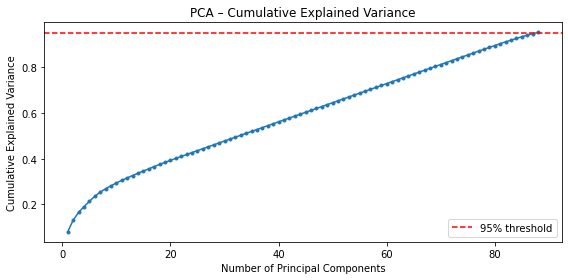

In [32]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=150)
plt.show()

In [33]:
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [34]:
start = time.time()
rf_pca.fit(X_train_pca, y_train)
pca_train_time = time.time() - start

print("\nTraining time (with PCA):", pca_train_time, "s")


Training time (with PCA): 24.870333194732666 s


In [35]:
y_pred_pca  = rf_pca.predict(X_test_pca)
y_proba_pca = rf_pca.predict_proba(X_test_pca)[:, 1]

In [36]:
print("\n\t\tResults WITH PCA")
print("Accuracy :", accuracy_score(y_test, y_pred_pca))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_pca))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))


		Results WITH PCA
Accuracy : 0.9971819805516967
ROC-AUC  : 0.9999726948940952

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1))
])

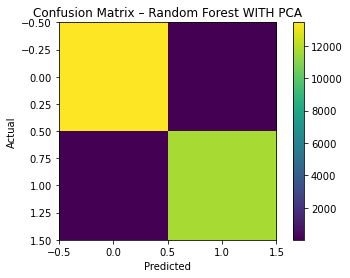

In [38]:
cm_pca = confusion_matrix(y_test, y_pred_pca)
plt.figure()
plt.imshow(cm_pca)
plt.title("Confusion Matrix – Random Forest WITH PCA")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_pca.png", dpi=150)
plt.show()

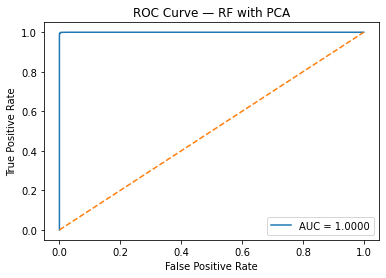

In [39]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba_pca)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — RF with PCA")
plt.legend()
plt.show()

In [40]:
scores = cross_val_score(pipeline, X, y, cv=5)
print("CV Accuracy:", scores.mean(), "+/-", scores.std())

CV Accuracy: 0.9973962716121862 +/- 0.0002846364339248222
